In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/bank-full.csv", sep=";")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [2]:
print("Subscription counts:")
print(df["y"].value_counts())

print("\nSubscription percentages:")
print(df["y"].value_counts(normalize=True).mul(100).round(2))

print("\nMissing values:")
print(df.isna().sum())

Subscription counts:
y
no     39922
yes     5289
Name: count, dtype: int64

Subscription percentages:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64

Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [3]:
features = [
    "age", "job", "marital", "education",
    "default", "balance", "housing", "loan",
]

X = df[features].copy()
y = df["y"].map({"no": 0, "yes": 1})

assert y.notna().all()
assert "duration" not in X.columns

print("Model inputs:", X.shape)
print("Subscription rate:", f"{y.mean():.2%}")

Model inputs: (45211, 8)
Subscription rate: 11.70%


In [4]:
train_end = int(len(X) * 0.60)
valid_end = int(len(X) * 0.80)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_valid = X.iloc[train_end:valid_end]
y_valid = y.iloc[train_end:valid_end]

X_test = X.iloc[valid_end:]
y_test = y.iloc[valid_end:]

for name, target in [
    ("Training", y_train),
    ("Validation", y_valid),
    ("Test", y_test),
]:
    print(
        f"{name}: {len(target):,} rows, "
        f"subscription rate {target.mean():.2%}"
    )

Training: 27,126 rows, subscription rate 5.04%
Validation: 9,042 rows, subscription rate 11.79%
Test: 9,043 rows, subscription rate 31.58%


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

numeric_features = ["age", "balance"]
categorical_features = [
    "job", "marital", "education",
    "default", "housing", "loan",
]

preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_features),
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_features,
    ),
])

logistic_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42)),
])

logistic_model.fit(X_train, y_train)

print("Logistic regression trained.")

Logistic regression trained.


In [6]:
import numpy as np
from sklearn.metrics import brier_score_loss

valid_probabilities = logistic_model.predict_proba(X_valid)[:, 1]

contact_count = int(np.ceil(len(X_valid) * 0.10))

# Stable sorting makes ties reproducible.
ranked_positions = np.argsort(
    -valid_probabilities, kind="stable"
)
selected_positions = ranked_positions[:contact_count]

subscribers_captured = int(
    y_valid.iloc[selected_positions].sum()
)
total_subscribers = int(y_valid.sum())

precision_at_10 = subscribers_captured / contact_count
recall_at_10 = subscribers_captured / total_subscribers
random_precision = y_valid.mean()
lift_at_10 = precision_at_10 / random_precision
brier = brier_score_loss(y_valid, valid_probabilities)

print(f"Customers selected: {contact_count:,}")
print(f"Historical subscribers captured: {subscribers_captured:,}")
print(f"Precision@10%: {precision_at_10:.2%}")
print(f"Recall@10%: {recall_at_10:.2%}")
print(f"Lift over random selection: {lift_at_10:.2f}x")
print(f"Brier score: {brier:.4f}")

Customers selected: 905
Historical subscribers captured: 187
Precision@10%: 20.66%
Recall@10%: 17.54%
Lift over random selection: 1.75x
Brier score: 0.1075


In [7]:
from sklearn.base import clone
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)

random_forest_model = Pipeline([
    ("preprocessing", clone(preprocessor)),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1,
    )),
])

gradient_boosting_model = Pipeline([
    ("preprocessing", clone(preprocessor)),
    ("model", GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=10,
        random_state=42,
    )),
])

models = {
    "Logistic regression": logistic_model,
    "Random forest": random_forest_model,
    "Gradient boosting": gradient_boosting_model,
}

for name, model in models.items():
    if name != "Logistic regression":
        model.fit(X_train, y_train)
    print(f"{name}: trained")

Logistic regression: trained
Random forest: trained
Gradient boosting: trained


In [10]:
def evaluate_ranking(target, probabilities, capacity=0.10):
    target = np.asarray(target)
    probabilities = np.asarray(probabilities)

    count = max(1, int(np.floor(len(target) * capacity)))
    selected = np.argsort(
        -probabilities, kind="stable"
    )[:count]

    captured = int(target[selected].sum())
    total_subscribers = int(target.sum())
    base_rate = target.mean()

    return {
        "selected": count,
        "captured": captured,
        "precision": captured / count,
        "recall": (
            captured / total_subscribers
            if total_subscribers else np.nan
        ),
        "lift": (
            (captured / count) / base_rate
            if base_rate else np.nan
        ),
        "brier": brier_score_loss(target, probabilities),
    }


validation_predictions = {}
validation_results = {}

for name, model in models.items():
    probabilities = model.predict_proba(X_valid)[:, 1]
    validation_predictions[name] = probabilities

    result = evaluate_ranking(y_valid, probabilities)
    validation_results[name] = result

    print(f"\n{name}")
    print(f"Historical subscribers captured: {result['captured']}")
    print(f"Precision@10%: {result['precision']:.2%}")
    print(f"Recall@10%: {result['recall']:.2%}")
    print(f"Lift@10%: {result['lift']:.2f}x")
    print(f"Brier score: {result['brier']:.4f}")


Logistic regression
Historical subscribers captured: 187
Precision@10%: 20.69%
Recall@10%: 17.54%
Lift@10%: 1.75x
Brier score: 0.1075

Random forest
Historical subscribers captured: 197
Precision@10%: 21.79%
Recall@10%: 18.48%
Lift@10%: 1.85x
Brier score: 0.1063

Gradient boosting
Historical subscribers captured: 190
Precision@10%: 21.02%
Recall@10%: 17.82%
Lift@10%: 1.78x
Brier score: 0.1070


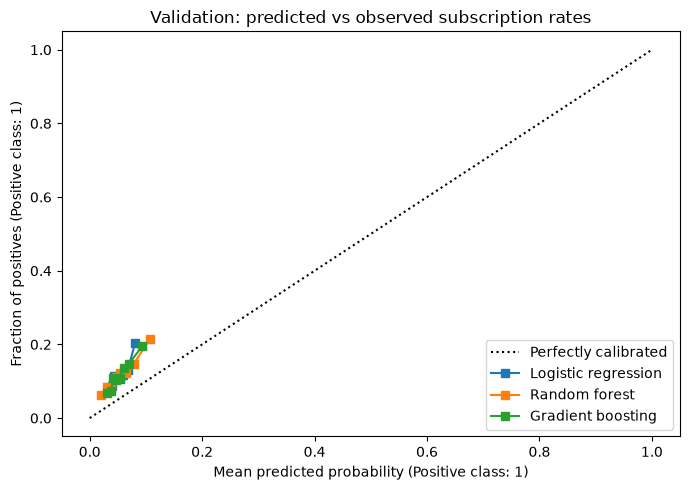

In [11]:
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(7, 5))

for name, probabilities in validation_predictions.items():
    CalibrationDisplay.from_predictions(
        y_valid,
        probabilities,
        n_bins=8,
        strategy="quantile",
        name=name,
        ax=ax,
    )

ax.set_title("Validation: predicted vs observed subscription rates")
plt.tight_layout()
plt.show()

In [12]:
best_model_name = max(
    validation_results,
    key=lambda name: validation_results[name]["precision"],
)

best_model = models[best_model_name]
best_probabilities = validation_predictions[best_model_name]

print("Provisional model:", best_model_name)

Provisional model: Random forest


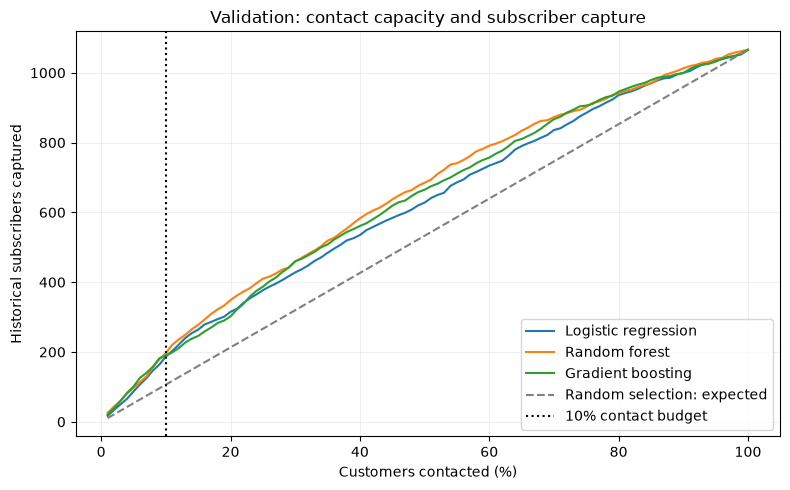

In [13]:
capacities = np.arange(0.01, 1.01, 0.01)

fig, ax = plt.subplots(figsize=(8, 5))

for name, probabilities in validation_predictions.items():
    captured = [
        evaluate_ranking(
            y_valid, probabilities, capacity
        )["captured"]
        for capacity in capacities
    ]

    ax.plot(
        capacities * 100,
        captured,
        label=name,
    )

# Expected capture under random selection using the same budgets
random_capture = [
    int(np.floor(len(y_valid) * capacity)) * y_valid.mean()
    for capacity in capacities
]

ax.plot(
    capacities * 100,
    random_capture,
    linestyle="--",
    color="grey",
    label="Random selection: expected",
)

ax.axvline(
    10,
    color="black",
    linestyle=":",
    label="10% contact budget",
)

ax.set_xlabel("Customers contacted (%)")
ax.set_ylabel("Historical subscribers captured")
ax.set_title("Validation: contact capacity and subscriber capture")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [14]:
contact_count = int(np.floor(len(X_valid) * 0.10))

ranked_customers = X_valid.copy()
ranked_customers.insert(
    0, "record_id", ranked_customers.index
)
ranked_customers["predicted_probability"] = best_probabilities

ranked_customers = ranked_customers.sort_values(
    "predicted_probability",
    ascending=False,
    kind="stable",
)

campaign_list = ranked_customers.head(contact_count).copy()
campaign_list.insert(
    0, "priority_rank", np.arange(1, len(campaign_list) + 1)
)

print(f"Campaign contact list: {len(campaign_list):,} records")
campaign_list.head(10)

Campaign contact list: 904 records


,priority_rank,record_id,age,job,marital,education,default,balance,housing,loan,predicted_probability
31233,1,31233,94,retired,divorced,secondary,no,1234,no,no,0.202809
34150,2,34150,61,retired,divorced,secondary,no,927,no,no,0.199472
28228,3,28228,42,blue-collar,divorced,primary,no,299,yes,no,0.197832
31062,4,31062,63,retired,divorced,secondary,no,859,no,no,0.197682
27900,5,27900,59,retired,divorced,secondary,no,914,no,no,0.193402
33536,6,33536,41,blue-collar,divorced,primary,no,285,yes,no,0.186764
34943,7,34943,27,blue-collar,single,secondary,yes,-233,yes,no,0.183028
29333,8,29333,41,blue-collar,divorced,primary,no,320,yes,no,0.178041
31148,9,31148,37,technician,single,secondary,no,1130,no,no,0.174554
30520,10,30520,50,technician,single,secondary,no,1022,no,no,0.173679


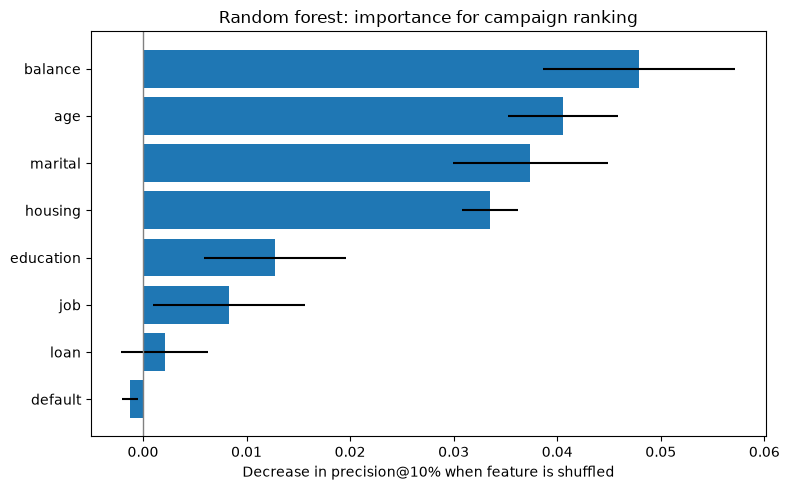

In [15]:
from sklearn.inspection import permutation_importance

def precision_at_10_scorer(estimator, inputs, target):
    probabilities = estimator.predict_proba(inputs)[:, 1]
    return evaluate_ranking(
        target, probabilities, capacity=0.10
    )["precision"]

importance = permutation_importance(
    best_model,
    X_valid,
    y_valid,
    scoring=precision_at_10_scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

feature_importance = pd.Series(
    importance.importances_mean,
    index=X_valid.columns,
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    feature_importance.index,
    feature_importance.values,
    xerr=pd.Series(
        importance.importances_std,
        index=X_valid.columns,
    ).loc[feature_importance.index],
)

ax.axvline(0, color="grey", linewidth=1)
ax.set_xlabel("Decrease in precision@10% when feature is shuffled")
ax.set_title(f"{best_model_name}: importance for campaign ranking")

plt.tight_layout()
plt.show()

In [16]:
model_probabilities = pd.DataFrame(
    validation_predictions,
    index=X_valid.index,
)

# Higher percentile = higher priority within that model
model_rank_percentiles = model_probabilities.rank(
    pct=True,
    method="average",
)

rank_spread = (
    model_rank_percentiles.max(axis=1)
    - model_rank_percentiles.min(axis=1)
)

review_list = ranked_customers.copy()
review_list["rank_disagreement"] = rank_spread.reindex(
    review_list.index
)

# Illustrative threshold: models differ by at least 20 percentile points
review_list["models_disagree"] = (
    review_list["rank_disagreement"] >= 0.20
)

review_list["priority_rank"] = np.arange(
    1, len(review_list) + 1
)

# Flag a band around the selection boundary
boundary_band = max(1, int(len(review_list) * 0.01))

review_list["near_budget_cutoff"] = (
    review_list["priority_rank"] - contact_count
).abs() <= boundary_band

review_list["review_flag"] = (
    review_list["models_disagree"]
    | review_list["near_budget_cutoff"]
)

campaign_list = review_list.head(contact_count).copy()

print(f"Selected records: {len(campaign_list):,}")
print(
    "Selected records flagged for review:",
    int(campaign_list["review_flag"].sum()),
)

campaign_list[[
    "priority_rank",
    "record_id",
    "predicted_probability",
    "rank_disagreement",
    "models_disagree",
    "near_budget_cutoff",
    "review_flag",
]].head(15)

Selected records: 904
Selected records flagged for review: 404


,priority_rank,record_id,predicted_probability,rank_disagreement,models_disagree,near_budget_cutoff,review_flag
31233,1,31233,0.202809,0.425680,True,False,True
34150,2,34150,0.199472,0.053196,False,False,False
28228,3,28228,0.197832,0.231918,True,False,True
31062,4,31062,0.197682,0.068127,False,False,False
27900,5,27900,0.193402,0.041363,False,False,False
33536,6,33536,0.186764,0.265649,True,False,True
34943,7,34943,0.183028,0.154944,False,False,False
29333,8,29333,0.178041,0.219420,True,False,True
31148,9,31148,0.174554,0.240102,True,False,True
30520,10,30520,0.173679,0.413957,True,False,True


In [17]:
calibration_end = len(X_valid) // 2

X_calibration = X_valid.iloc[:calibration_end]
y_calibration = y_valid.iloc[:calibration_end]

X_assessment = X_valid.iloc[calibration_end:]
y_assessment = y_valid.iloc[calibration_end:]

for name, target in [
    ("Calibration", y_calibration),
    ("Assessment", y_assessment),
]:
    print(
        f"{name}: {len(target):,} records, "
        f"subscription rate {target.mean():.2%}"
    )

Calibration: 4,521 records, subscription rate 10.46%
Assessment: 4,521 records, subscription rate 13.12%


In [18]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

calibrated_model = CalibratedClassifierCV(
    estimator=FrozenEstimator(best_model),
    method="sigmoid",
)

calibrated_model.fit(X_calibration, y_calibration)

print("Calibration fitted.")

Calibration fitted.


In [19]:
raw_probabilities = best_model.predict_proba(
    X_assessment
)[:, 1]

calibrated_probabilities = calibrated_model.predict_proba(
    X_assessment
)[:, 1]

assessment_results = {}

for name, probabilities in [
    ("Original", raw_probabilities),
    ("Calibrated", calibrated_probabilities),
]:
    result = evaluate_ranking(y_assessment, probabilities)
    assessment_results[name] = result

    print(f"\n{name}")
    print(f"Brier score: {result['brier']:.4f}")
    print(f"Mean predicted probability: {probabilities.mean():.2%}")
    print(f"Actual subscription rate: {y_assessment.mean():.2%}")
    print(f"Precision@10%: {result['precision']:.2%}")
    print(f"Recall@10%: {result['recall']:.2%}")
    print(f"Lift@10%: {result['lift']:.2f}x")


Original
Brier score: 0.1181
Mean predicted probability: 5.27%
Actual subscription rate: 13.12%
Precision@10%: 26.99%
Recall@10%: 20.57%
Lift@10%: 2.06x

Calibrated
Brier score: 0.1126
Mean predicted probability: 9.90%
Actual subscription rate: 13.12%
Precision@10%: 26.99%
Recall@10%: 20.57%
Lift@10%: 2.06x


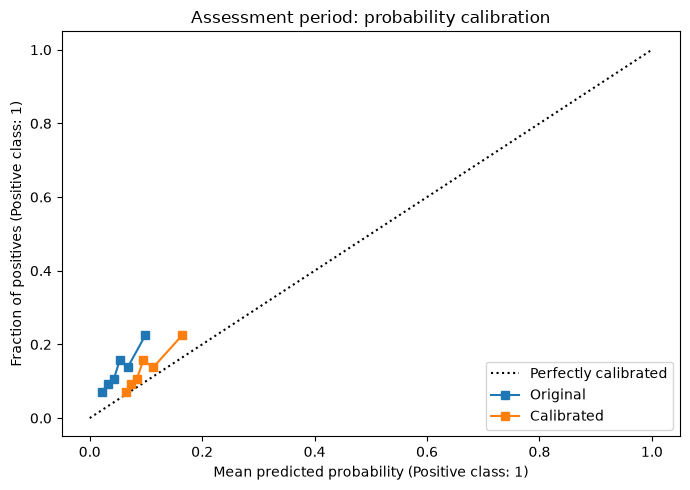

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, probabilities in [
    ("Original", raw_probabilities),
    ("Calibrated", calibrated_probabilities),
]:
    CalibrationDisplay.from_predictions(
        y_assessment,
        probabilities,
        n_bins=6,
        strategy="quantile",
        name=name,
        ax=ax,
    )

ax.set_title("Assessment period: probability calibration")
plt.tight_layout()
plt.show()

In [21]:
final_model = calibrated_model
final_model_name = "Calibrated random forest"

print("Chosen model:", final_model_name)
print("Features:", features)
print("Contact budget: 10%")

Chosen model: Calibrated random forest
Features: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan']
Contact budget: 10%


In [22]:
test_models = {
    **models,
    final_model_name: final_model,
}

test_predictions = {}
test_results = {}

for name, model in test_models.items():
    probabilities = model.predict_proba(X_test)[:, 1]
    result = evaluate_ranking(y_test, probabilities)

    test_predictions[name] = probabilities
    test_results[name] = result

    print(f"\n{name}")
    print(f"Records selected: {result['selected']:,}")
    print(f"Historical subscribers captured: {result['captured']:,}")
    print(f"Precision@10%: {result['precision']:.2%}")
    print(f"Recall@10%: {result['recall']:.2%}")
    print(f"Lift@10%: {result['lift']:.2f}x")
    print(f"Brier score: {result['brier']:.4f}")
    print(f"Mean predicted probability: {probabilities.mean():.2%}")

print(f"\nActual test subscription rate: {y_test.mean():.2%}")


Logistic regression
Records selected: 904
Historical subscribers captured: 422
Precision@10%: 46.68%
Recall@10%: 14.78%
Lift@10%: 1.48x
Brier score: 0.2829
Mean predicted probability: 5.49%

Random forest
Records selected: 904
Historical subscribers captured: 384
Precision@10%: 42.48%
Recall@10%: 13.45%
Lift@10%: 1.34x
Brier score: 0.2774
Mean predicted probability: 6.20%

Gradient boosting
Records selected: 904
Historical subscribers captured: 400
Precision@10%: 44.25%
Recall@10%: 14.01%
Lift@10%: 1.40x
Brier score: 0.2806
Mean predicted probability: 5.77%

Calibrated random forest
Records selected: 904
Historical subscribers captured: 384
Precision@10%: 42.48%
Recall@10%: 13.45%
Lift@10%: 1.34x
Brier score: 0.2542
Mean predicted probability: 11.17%

Actual test subscription rate: 31.58%


In [23]:
baseline_probabilities = np.full(
    len(y_test),
    y_calibration.mean(),
)

baseline_brier = brier_score_loss(
    y_test,
    baseline_probabilities,
)

chosen_brier = test_results[final_model_name]["brier"]

print(f"Constant-probability baseline Brier: {baseline_brier:.4f}")
print(f"Chosen model Brier: {chosen_brier:.4f}")
print("Lower Brier is better.")

Constant-probability baseline Brier: 0.2607
Chosen model Brier: 0.2542
Lower Brier is better.


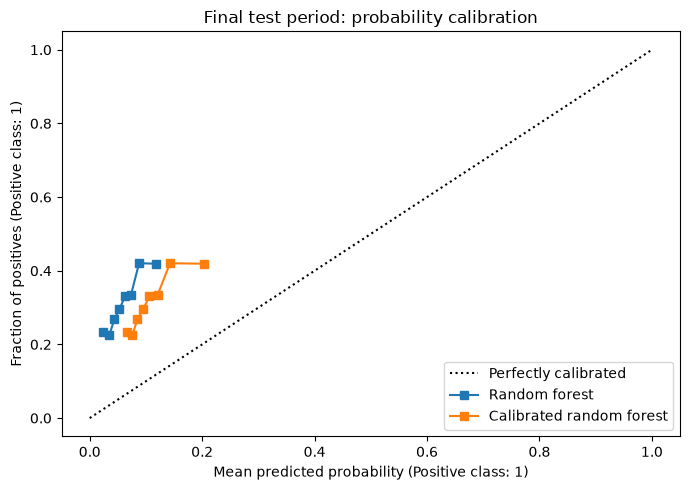

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))

for name in ["Random forest", final_model_name]:
    CalibrationDisplay.from_predictions(
        y_test,
        test_predictions[name],
        n_bins=8,
        strategy="quantile",
        name=name,
        ax=ax,
    )

ax.set_title("Final test period: probability calibration")
plt.tight_layout()
plt.show()

In [25]:
# Choose the highest-ranked test record
final_test_probabilities = test_predictions[final_model_name]

top_position = np.argsort(
    -final_test_probabilities, kind="stable"
)[0]

customer = X_test.iloc[[top_position]].copy()
original_probability = final_model.predict_proba(customer)[0, 1]

# Reference values come from training data only
reference_values = {}

for feature in numeric_features:
    reference_values[feature] = X_train[feature].median()

for feature in categorical_features:
    reference_values[feature] = X_train[feature].mode().iloc[0]

effects = []

for feature in features:
    modified_customer = customer.copy()
    modified_customer[feature] = reference_values[feature]

    modified_probability = final_model.predict_proba(
        modified_customer
    )[0, 1]

    effects.append({
        "feature": feature,
        "customer_value": customer.iloc[0][feature],
        "reference_value": reference_values[feature],
        "probability_difference": (
            original_probability - modified_probability
        ),
    })

local_explanation = pd.DataFrame(effects).set_index("feature")

print("Record ID:", customer.index[0])
print(f"Predicted probability: {original_probability:.2%}")

local_explanation

Record ID: 40726
Predicted probability: 46.38%


,customer_value,reference_value,probability_difference
feature,,,
age,73,40.0,2.776927e-01
job,retired,blue-collar,2.860360e-01
marital,divorced,married,3.171829e-01
education,secondary,secondary,1.110223e-16
default,no,no,-2.775558e-16
balance,1092,378.0,2.678285e-01
housing,no,yes,2.430699e-01
loan,no,no,1.110223e-16


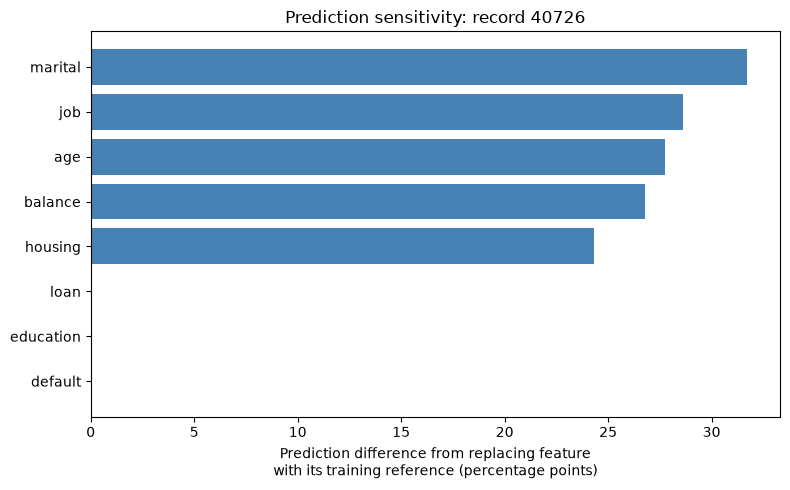

In [26]:
differences = local_explanation[
    "probability_difference"
].sort_values() * 100

colors = [
    "steelblue" if value >= 0 else "coral"
    for value in differences
]

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(differences.index, differences.values, color=colors)
ax.axvline(0, color="grey")
ax.set_xlabel(
    "Prediction difference from replacing feature\n"
    "with its training reference (percentage points)"
)
ax.set_title(f"Prediction sensitivity: record {customer.index[0]}")

plt.tight_layout()
plt.show()

In [27]:
from pathlib import Path
import json
import joblib

artifact_dir = Path("../artifacts")
artifact_dir.mkdir(exist_ok=True)

joblib.dump(
    {
        "models": models,
        "final_model": final_model,
        "final_model_name": final_model_name,
        "features": features,
        "reference_values": reference_values,
    },
    artifact_dir / "campaign_models.joblib",
)

with (artifact_dir / "test_results.json").open("w") as file:
    json.dump(test_results, file, indent=2)

print("Saved models and test results.")

Saved models and test results.
